# Desafio Final — Transcrição de Cardápios com LLM Multimodal

Prova de conceito que transcreve fotos de cardápios de restaurante em dados estruturados (`Produto`, `Preço`) usando um LLM multimodal (Google Gemini), inspirada no pipeline descrito pela engenharia da DoorDash:

- [Using LLM to Transcribe Restaurant Menu Photos](https://doordash.engineering/2022/09/07/using-llm-to-transcribe-restaurant-menu-photos/)
- [How DoorDash Uses AI Models to Understand Restaurant Menus](https://doordash.engineering/2023/08/15/how-doordash-uses-ai-models-to-understand-restaurant-menus/)

Este notebook é a **entrega oficial** do Desafio Final do bootcamp *Projetista em IA Generativa* (XP Educação). Ele demonstra, célula a célula, cada etapa do pipeline construído em `src/` ao longo das PRs anteriores, e executa o fluxo completo com duas fotos de cardápio reais.

O repositório com o código completo está disponível em https://github.com/viniwenz/menu_transcription_poc

## Arquitetura

```
foto do cardápio
      ↓
 pré-processamento (validação, resize)      → src/image_utils.py
      ↓
 Gemini API (multimodal prompt)             → src/llm_client.py
      ↓
 parser → estrutura {Produto, Preço}        → src/parser.py
      ↓
 guardrails (validação, retry)              → src/guardrails.py
      ↓
 Gradio UI (tabela estruturada)             → src/app.py (não usada aqui — ver `python main.py`)
```


## 1. Setup

Importamos os módulos do pacote `src/`, cada um responsável por uma etapa do pipeline, e instanciamos o cliente Gemini (a chave `GEMINI_API_KEY` é lida do `.env` na raiz do projeto).

In [1]:
import sys
from pathlib import Path

# permite importar o pacote `src` quando o notebook roda a partir de notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import pandas as pd

from src.image_utils import load_image, validate_image, encode_image_bytes
from src.llm_client import GeminiClient
from src.parser import parse_menu_response
from src.guardrails import validate_menu, transcribe_with_retry

SAMPLES_DIR = project_root / "samples"
client = GeminiClient()
print("Cliente Gemini pronto.")

Cliente Gemini pronto.


## 2. Pré-processamento de imagem (`src/image_utils.py`)

`load_image` lê o arquivo do disco e valida que não está corrompido. `validate_image` confere formato (JPEG/PNG/WEBP) e dimensões. `encode_image_bytes` redimensiona (se necessário) e converte para bytes JPEG prontos para envio à API.

Vamos carregar a primeira imagem de exemplo:

Imagem: cardapio_1.jpg | formato=JPEG | tamanho=(376, 531)


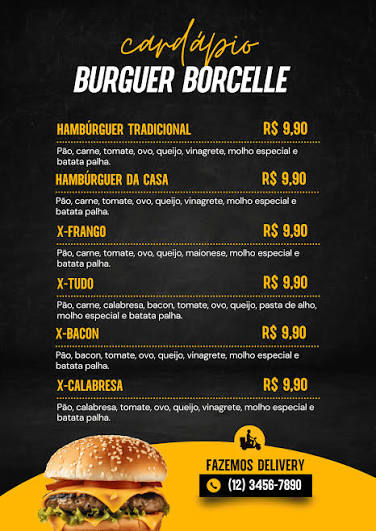

In [2]:
image_path_1 = SAMPLES_DIR / "cardapio_1.jpg"

img1 = load_image(str(image_path_1))
validate_image(img1)

print(f"Imagem: {image_path_1.name} | formato={img1.format} | tamanho={img1.size}")
img1

## 3. Chamada à API Gemini (`src/llm_client.py`)

`GeminiClient.transcribe_menu` envia a imagem (como bytes) junto de um prompt de sistema que pede explicitamente uma tabela markdown `Produto | Preço`.

In [3]:
image_bytes_1 = encode_image_bytes(img1)
raw_response_1 = client.transcribe_menu(image_bytes_1)
print(raw_response_1)

| Produto | Preço |
|---------|-------|
| HAMBÚRGUER TRADICIONAL | R$ 9,90 |
| HAMBÚRGUER DA CASA | R$ 9,90 |
| X-FRANGO | R$ 9,90 |
| X-TUDO | R$ 9,90 |
| X-BACON | R$ 9,90 |
| X-CALABRESA | R$ 9,90 |


## 4. Parser da resposta (`src/parser.py`)

`parse_menu_response` converte o texto bruto da LLM (tabela markdown, JSON ou texto simples) em uma lista de dicts `{"produto": ..., "preco": ...}`, já com os preços normalizados para o formato `R$ XX,XX`.

In [4]:
items_1 = parse_menu_response(raw_response_1)
pd.DataFrame(items_1)

,produto,preco
0,HAMBÚRGUER TRADICIONAL,"R$ 9,90"
1,HAMBÚRGUER DA CASA,"R$ 9,90"
2,X-FRANGO,"R$ 9,90"
3,X-TUDO,"R$ 9,90"
4,X-BACON,"R$ 9,90"
5,X-CALABRESA,"R$ 9,90"


## 5. Guardrails e validação (`src/guardrails.py`)

`validate_menu` confere que a lista não está vazia, que os nomes dos produtos não são vazios e que os preços estão no formato esperado. Se a validação falhar, `transcribe_with_retry` repete a chamada à API (até 2 tentativas) com um prompt refinado.

In [5]:
result_1 = validate_menu(items_1)
print(f"Válido: {result_1.valid}")
print(f"Erros: {result_1.errors}")

Válido: True
Erros: []


## 6. Pipeline completo (função reutilizável)

Reunimos as etapas acima — usando `transcribe_with_retry`, que já encapsula parsing + validação + retry automático — em uma única função, para demonstrar o fluxo ponta a ponta em duas fotos de cardápio diferentes.

In [6]:
def transcrever_cardapio(path: str) -> pd.DataFrame:
    img = load_image(path)
    validate_image(img)
    image_bytes = encode_image_bytes(img)
    items = transcribe_with_retry(image_bytes, client)
    return pd.DataFrame(items)

### Exemplo 1 — `cardapio_1.jpg`

In [7]:
transcrever_cardapio(str(SAMPLES_DIR / "cardapio_1.jpg"))

,produto,preco
0,HAMBÚRGUER TRADICIONAL,"R$ 9,90"
1,HAMBÚRGUER DA CASA,"R$ 9,90"
2,X-FRANGO,"R$ 9,90"
3,X-TUDO,"R$ 9,90"
4,X-BACON,"R$ 9,90"
5,X-CALABRESA,"R$ 9,90"


### Exemplo 2 — `cardapio_2.jpg`

In [8]:
transcrever_cardapio(str(SAMPLES_DIR / "cardapio_2.jpg"))

,produto,preco
0,POKE TRADICIONAL,"R$ 35,00"
1,POKE VEGANO,"R$ 33,00"
2,POKE DE CAMARÃO,"R$ 39,00"
3,POKE DE FRANGO,"R$ 31,00"


## Conclusão

O pipeline transcreveu com sucesso dois cardápios diferentes (um de hambúrgueres, um de poke), reaproveitando integralmente os módulos de `src/` construídos nas PRs anteriores (processamento de imagem, integração com Gemini, parser e guardrails).

Para uma interface interativa (upload de imagem + tabela na UI), rode:

```bash
python main.py
```

E acesse `http://localhost:7860`.